In [1]:
!pip install ultralytics

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 46.7/46.7 kB 1.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 86.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 91.0/91.0 kB 10.8 MB/s eta 0:00:00


In [2]:
from ultralytics import YOLO
import torch

print("Ultralytics imported successfully!")
print("CUDA available:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

Creating new Ultralytics Settings v0.0.8 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/usage/settings.
Ultralytics imported successfully!
CUDA available: True
GPU: Tesla T4


In [3]:
from ultralytics import YOLO

# Load pretrained YOLO model
model = YOLO("yolo11n.pt")

print("YOLO model loaded successfully!")


YOLO model loaded successfully!


In [4]:
import os

dataset_path = "/content/coco8"

# Download COCO8 dataset automatically
model.train(
    data="coco8.yaml",
    epochs=1,
    imgsz=640,
    device=0
)

print("Dataset downloaded and test training completed!")

Ultralytics 8.4.164 🚀 Python-3.13.15 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, channels_last=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=coco8.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dgrad=0.5, dis=6.0, distill_model=None, dlam=1.0, dlog=1.0, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=1, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, iou=0.7, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo11n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=train, nbs=64, nms=None, opset=None, optimize=False, optimizer=auto, overlap_ma

In [5]:
from ultralytics import YOLO

# Load the model trained in Step 4
trained_model = YOLO("/content/runs/detect/train/weights/best.pt")

# Validate the model
metrics = trained_model.val()

print("Validation completed successfully!")
print("mAP50:", metrics.box.map50)
print("mAP50-95:", metrics.box.map)

Ultralytics 8.4.164 🚀 Python-3.13.15 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
YOLO11n summary (fused): 100 layers, 2,616,248 parameters, 0 gradients, 6.5 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 1354.5±438.4 MB/s, size: 54.0 KB)
val: Scanning /content/datasets/coco8/labels/val.cache... 4 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 4/4 1.0Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 1/1 11.1it/s 0.1s
                   all          4         17       0.57       0.85      0.846       0.63
                person          3         10      0.557        0.6      0.581      0.268
                   dog          1          1      0.548          1      0.995      0.697
                 horse          1          2      0.531          1      0.995      0.671
              elephant          1          2      0.371        0.5      0.516      0.256
              umbrella          1          1    

In [7]:
import os

folders = [
    "/content/bottle_dataset/images/train",
    "/content/bottle_dataset/images/val",
    "/content/bottle_dataset/labels/train",
    "/content/bottle_dataset/labels/val"
]

for folder in folders:
    os.makedirs(folder, exist_ok=True)

print("Bottle dataset folders created successfully!")

Bottle dataset folders created successfully!


In [8]:


yaml_content = """
path: /content/bottle_dataset
train: images/train
val: images/val

names:
  0: bottle
"""

with open("/content/bottle_dataset/data.yaml", "w") as f:
    f.write(yaml_content)

print("data.yaml created successfully!")

# Display the file
with open("/content/bottle_dataset/data.yaml", "r") as f:
    print(f.read())

data.yaml created successfully!

path: /content/bottle_dataset
train: images/train
val: images/val

names:
  0: bottle



Please upload a photo containing a bottle.


Saving bottle.jpeg to bottle.jpeg

image 1/1 /content/bottle.jpeg: 640x640 1 vase, 8.1ms
Speed: 2.3ms preprocess, 8.1ms inference, 1.1ms postprocess per image at shape (1, 3, 640, 640)
Results saved to /content/runs/detect/predict-3


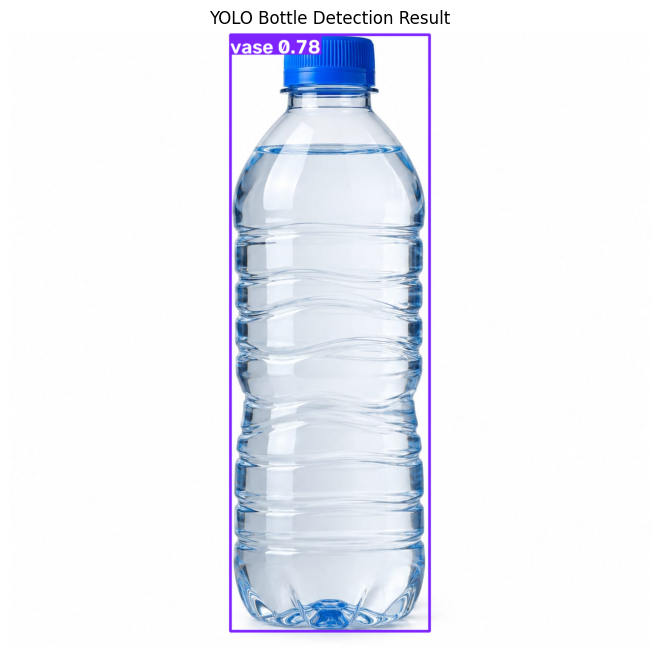

Object detection completed successfully!


In [11]:
from ultralytics import YOLO
from google.colab import files
from PIL import Image
import matplotlib.pyplot as plt

# Load pretrained YOLO model
bottle_model = YOLO("yolo11n.pt")

# Upload one bottle image
print("Please upload a photo containing a bottle.")
uploaded = files.upload()

image_path = list(uploaded.keys())[0]

# Detect objects
results = bottle_model.predict(
    source=image_path,
    conf=0.25,
    save=True
)

# Display detection result
result_image = results[0].plot()

plt.figure(figsize=(10, 8))
plt.imshow(result_image[:, :, ::-1])
plt.axis("off")
plt.title("YOLO Bottle Detection Result")
plt.show()

print("Object detection completed successfully!")


In [12]:
from ultralytics import YOLO

model = YOLO("yolo11n.pt")

results = model.train(
    data="/content/bottle_dataset/data.yaml",
    epochs=20,
    imgsz=640,
    device=0
)

print("Bottle model training completed!")

Ultralytics 8.4.164 🚀 Python-3.13.15 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, channels_last=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/bottle_dataset/data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dgrad=0.5, dis=6.0, distill_model=None, dlam=1.0, dlog=1.0, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=20, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, iou=0.7, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo11n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=train-2, nbs=64, nms=None, opset=None, optimize=False, 

FileNotFoundError: [34m[1mtrain: [0mError loading data from /content/bottle_dataset/images/train
See https://docs.ultralytics.com/datasets for dataset formatting guidance.

In [13]:
import os

folders = [
    "/content/bottle_dataset/images/train",
    "/content/bottle_dataset/images/val",
    "/content/bottle_dataset/labels/train",
    "/content/bottle_dataset/labels/val"
]

for folder in folders:
    files = os.listdir(folder)
    print(folder, ":", len(files), "files")
    print(files[:10])
    print()

/content/bottle_dataset/images/train : 0 files
[]

/content/bottle_dataset/images/val : 0 files
[]

/content/bottle_dataset/labels/train : 0 files
[]

/content/bottle_dataset/labels/val : 0 files
[]



In [21]:
import glob

weights = glob.glob("/content/runs/detect/**/weights/best.pt", recursive=True)
print(weights)

['/content/runs/detect/train-3/weights/best.pt', '/content/runs/detect/train/weights/best.pt']


Saving 33.jpg to 33.jpg

image 1/1 /content/33.jpg: 640x640 2 bottles, 1 spoon, 12.9ms
Speed: 2.7ms preprocess, 12.9ms inference, 1.7ms postprocess per image at shape (1, 3, 640, 640)


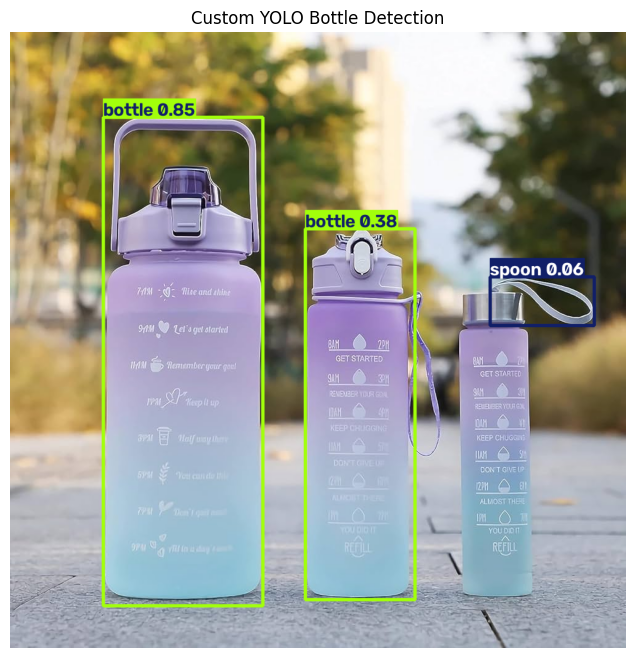

FINAL BOTTLE DETECTION COMPLETED!


In [23]:
from ultralytics import YOLO
from google.colab import files
import matplotlib.pyplot as plt

model = YOLO(weights[-1])

uploaded = files.upload()
img = list(uploaded.keys())[0]

results = model.predict(img, conf=0.05)

result_img = results[0].plot()

plt.figure(figsize=(8,8))
plt.imshow(result_img[:, :, ::-1])
plt.axis("off")
plt.title("Custom YOLO Bottle Detection")
plt.show()

print("FINAL BOTTLE DETECTION COMPLETED!")